In [1]:
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
red = pd.read_csv('reddit_data_example.csv')
red.head()

,Date,Domain,Sentiment,Language,Author,Thread Entry Type,Reddit Author Awardee Karma,Reddit Author Awarder Karma,Reddit Author Karma,Reddit Comments,Reddit Score,Reddit Score Upvote Ratio
0,2/9/2023 20:12,reddit.com,neutral,en,AutoModerator,reply,2397363,0,2000,NaN,1,NaN
1,2/9/2023 17:42,reddit.com,neutral,en,AutoModerator,reply,2397218,0,2000,NaN,1,NaN
2,2/9/2023 17:41,reddit.com,neutral,en,AutoModerator,reply,2397218,0,2000,NaN,1,NaN
3,2/8/2023 22:12,reddit.com,negative,en,KaylaST,reply,110,14,1470,NaN,1,NaN
4,2/8/2023 20:15,reddit.com,negative,en,CaveLady3000,post,311,73,4148,0.0,1,1.0


In [3]:
red.shape

(8137, 12)

In [4]:
red.columns

Index(['Date', 'Domain', 'Sentiment', 'Language', 'Author',
       'Thread Entry Type', 'Reddit Author Awardee Karma',
       'Reddit Author Awarder Karma', 'Reddit Author Karma', 'Reddit Comments',
       'Reddit Score', 'Reddit Score Upvote Ratio'],
      dtype='object')

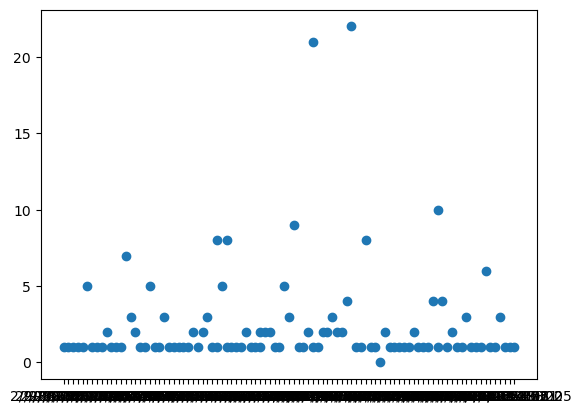

In [5]:
fig1, ax1 = plt.subplots()
ax1.scatter(x = red['Date'][0:100], y = red['Reddit Score'][0:100])

plt.show()

In [6]:
red['Date'].iloc[0]

'2/9/2023 20:12'

In [7]:
type(red['Date'].iloc[0])

str

In [8]:
pd.to_datetime(red['Date'].iloc[0])

Timestamp('2023-02-09 20:12:00')

In [9]:
red['datetime'] = pd.to_datetime(red['Date'])

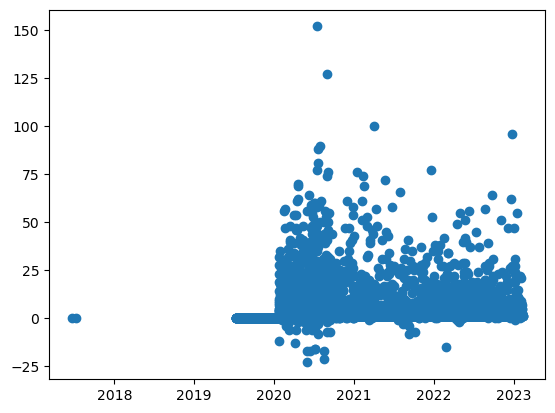

In [10]:
fig2, ax2 = plt.subplots()
ax2.scatter(x = red['datetime'], y = red['Reddit Score'])
plt.show()

In [11]:
post_2020 = red[red['datetime'] > pd.to_datetime('2020-01-01')]

In [12]:
post_2020.shape

(7158, 13)

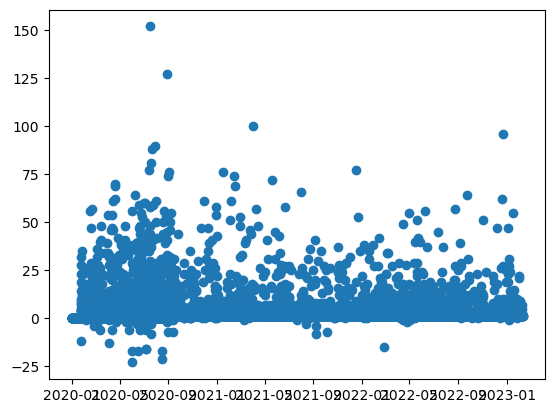

In [13]:
fig3, ax3 = plt.subplots()
ax3.scatter(x = post_2020['datetime'], y = post_2020['Reddit Score'])
plt.show()

In [14]:
red['datetime'].dt.date.iloc[0]

datetime.date(2023, 2, 9)

In [15]:
red['datetime'].iloc[0]

Timestamp('2023-02-09 20:12:00')

In [16]:
daily = red.groupby(red['datetime'].dt.date)['Reddit Score'].count()
# daily

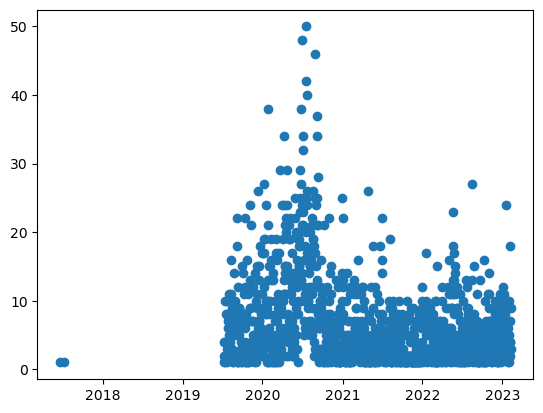

In [17]:
fig4, ax4 = plt.subplots()
ax4.scatter(x = daily.index, y = daily.values)
plt.show()

In [18]:
daily.index.max()

datetime.date(2023, 2, 9)

In [19]:
daily.index.min()

datetime.date(2017, 6, 20)

In [20]:
date_range_dt = pd.date_range(start = daily.index.min(), end = daily.index.max(), freq='D')
# date_range_dt

In [21]:
date_range = pd.date_range(start = '2017-06-20', end = '2023-02-09', freq='D')
rds = pd.Series(daily, index = date_range)
rds_zero_fill = rds.fillna(0)

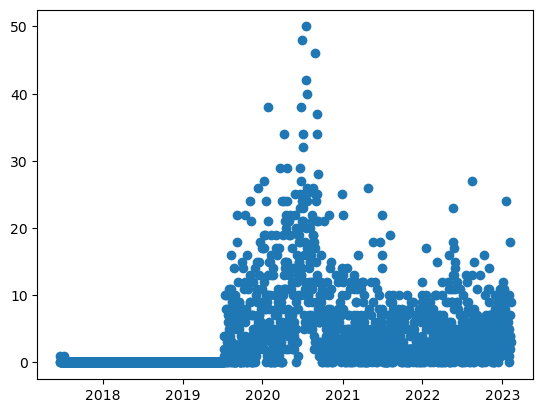

In [22]:
fig5, ax5 = plt.subplots()
ax5.scatter(x = rds_zero_fill.index, y = rds_zero_fill.values)
plt.show()

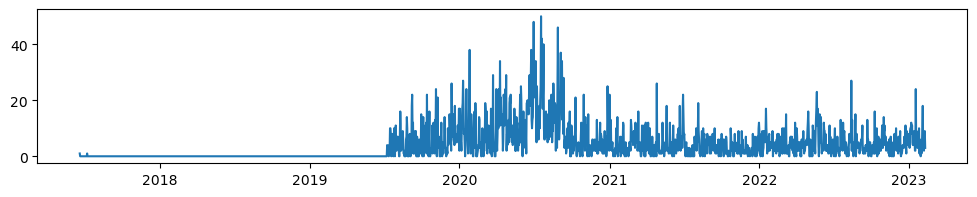

In [23]:
fig6, ax6 = plt.subplots(figsize = (12, 2))
ax6.plot(rds_zero_fill.index, rds_zero_fill.values)
plt.show()